In [1]:
!hostnamectl

 Static hostname: gpub081.delta.ncsa.illinois.edu
       Icon name: computer-server
         Chassis: server 🖳
      Machine ID: 81f2a3a0c8754cdb9ec6aae8833a8bc5
         Boot ID: cade28ccd1f74144bba9ea275e8698ef
Operating System: ]8;;https://www.redhat.com/Red Hat Enterprise Linux 9.4 (Plow)]8;;     
     CPE OS Name: cpe:/o:redhat:enterprise_linux:9::baseos
          Kernel: Linux 5.14.0-427.91.1.el9_4.x86_64
    Architecture: x86-64
Firmware Version: A48


In [2]:
import os
import scanpy as sc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import warnings

import moscot as mt
import moscot.plotting as mpl
from moscot.problems.time import TemporalProblem

In [4]:
plt.rcParams["legend.scatterpoints"] = 1
sc.set_figure_params(scanpy=True, dpi=80, dpi_save=200)

warnings.simplefilter("ignore", UserWarning)
warnings.simplefilter("ignore", FutureWarning)

In [3]:
rna_path = '/projects/bgdb/asachan/datasets/SKM_ageing_human/Myofiber_scsn_RNA.h5ad'

In [5]:
rna_adata = sc.read_h5ad(rna_path)
rna_adata

AnnData object with n_obs × n_vars = 150894 × 48355
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'sample', 'percent.mt', 'age', 'tech', 'Sex', 'Country', 'age_pop', 'Annotation', 'Pseudotime', 'Pseudotime_typeI', 'Pseudotime_typeII'
    var: 'features'
    uns: 'Final_annotation2_colors', 'Final_annotation3_colors', 'Final_annotation4_colors', 'Final_annotation_colors', 'age_pop_colors', 'anno_0713_colors', 'anno_0715_colors', 'fiber_class_V1_colors', 'integrated_snn_res.0.8_colors', 'integrated_snn_res.2.5_colors', 'integrated_snn_res.2_colors', 'integrated_snn_res.3_colors', 'integrated_snn_res.7_colors', 'rank_genes_groups'
    obsm: 'X_umap'

In [6]:
# subset to samples of interest
adata = rna_adata[rna_adata.obs['sample'].isin(['P26', 'YM2', 'OM6', 'OM9', 'P13', 'P5', 'OM5', 'OM7'])].copy()

In [7]:
adata

AnnData object with n_obs × n_vars = 88793 × 48355
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'sample', 'percent.mt', 'age', 'tech', 'Sex', 'Country', 'age_pop', 'Annotation', 'Pseudotime', 'Pseudotime_typeI', 'Pseudotime_typeII'
    var: 'features'
    uns: 'Final_annotation2_colors', 'Final_annotation3_colors', 'Final_annotation4_colors', 'Final_annotation_colors', 'age_pop_colors', 'anno_0713_colors', 'anno_0715_colors', 'fiber_class_V1_colors', 'integrated_snn_res.0.8_colors', 'integrated_snn_res.2.5_colors', 'integrated_snn_res.2_colors', 'integrated_snn_res.3_colors', 'integrated_snn_res.7_colors', 'rank_genes_groups'
    obsm: 'X_umap'

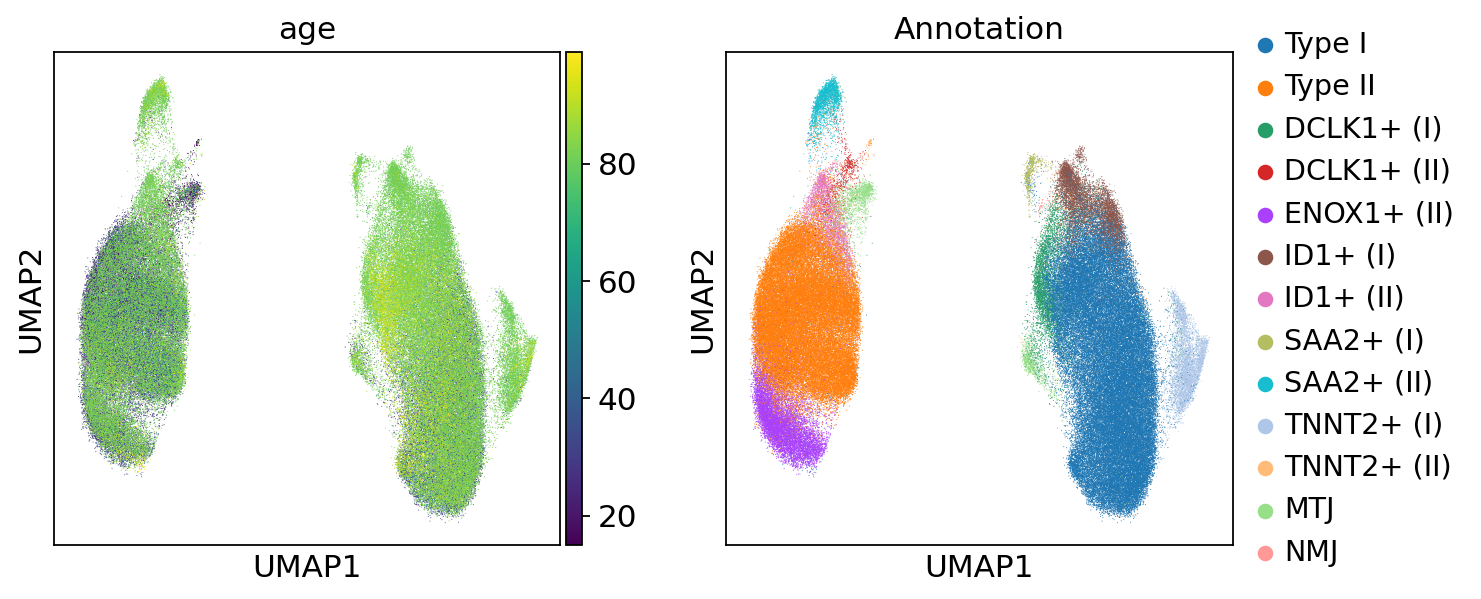

In [8]:
sc.pl.umap(rna_adata, color=['age', 'Annotation'])